In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
calories = pd.read_csv("calories_burnt_csv.csv")
exercise = pd.read_csv("exercise_prediction_csv.csv")

In [8]:
calories.head()

,User_ID,Calories
0,14733363,231
1,14861698,66
2,11179863,26
3,16180408,71
4,17771927,35


In [9]:
exercise.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190,94,29,105,40.8
1,14861698,female,20,166,60,14,94,40.3
2,11179863,male,69,179,79,5,88,38.7
3,16180408,female,34,179,71,13,100,40.5
4,17771927,female,27,154,58,10,81,39.8


In [10]:
#Gender	Age	Height	Weight	Duration	Heart_Rate	Body_Temp are the input features

In [20]:
#Merge the calories and exercise datasets
# df = exercise.merge(calories, on='User_ID')
# df.head()
calories_df = pd.concat([exercise.drop('User_ID',axis=1),calories['Calories']],axis=1)
calories_df

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,male,68,190,94,29,105,40.8,231
1,female,20,166,60,14,94,40.3,66
2,male,69,179,79,5,88,38.7,26
3,female,34,179,71,13,100,40.5,71
4,female,27,154,58,10,81,39.8,35
...,...,...,...,...,...,...,...,...
14994,female,48,159,57,10,94,39.8,52
14995,female,20,193,86,11,92,40.4,45
14996,female,27,165,65,6,85,39.2,23
14997,female,43,159,58,16,90,40.1,75


# EDA

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

In [22]:
calories_df.head(3)

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,male,68,190,94,29,105,40.8,231
1,female,20,166,60,14,94,40.3,66
2,male,69,179,79,5,88,38.7,26


<AxesSubplot:xlabel='Height', ylabel='Weight'>

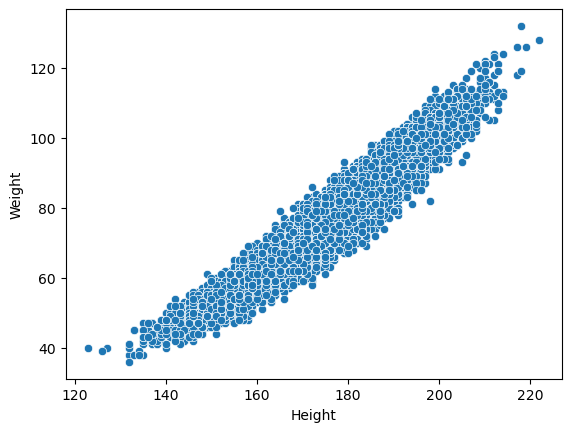

In [23]:
sns.scatterplot(x=calories_df['Height'],y=calories_df['Weight'])

<AxesSubplot:xlabel='Duration', ylabel='Heart_Rate'>

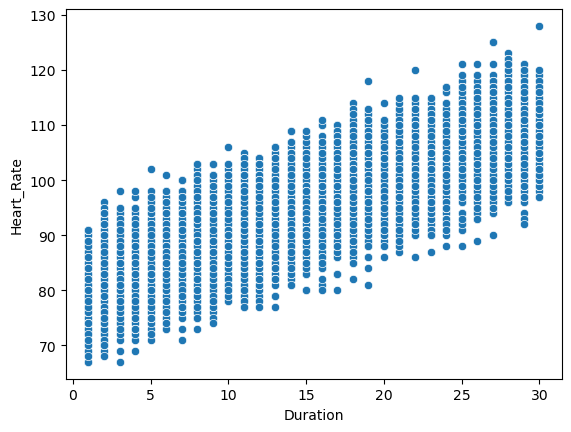

In [24]:
sns.scatterplot(x=calories_df['Duration'],y=calories_df['Heart_Rate'])

<AxesSubplot:xlabel='Gender', ylabel='count'>

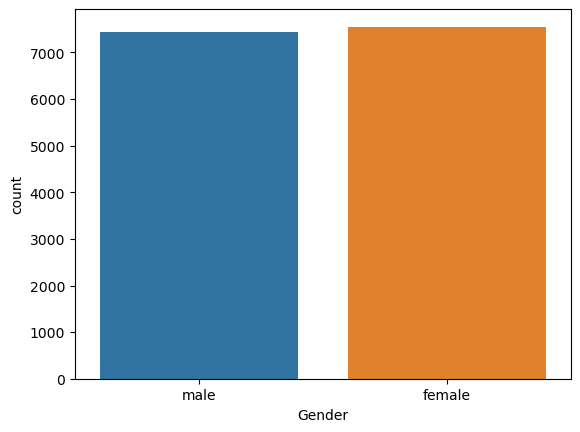

In [25]:
sns.countplot(x=calories_df['Gender'])

C:\Users\CSC\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


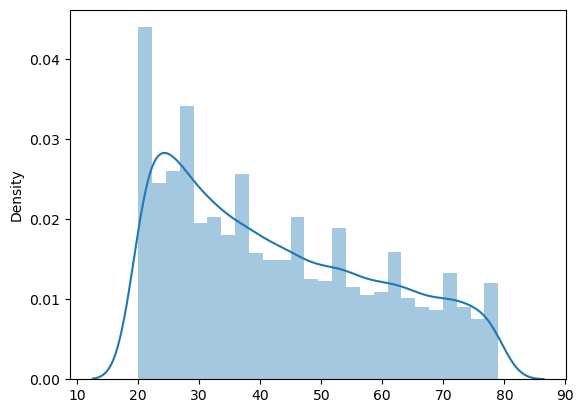

In [26]:
sns.distplot(x=calories_df['Age'])
plt.show()

C:\Users\CSC\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


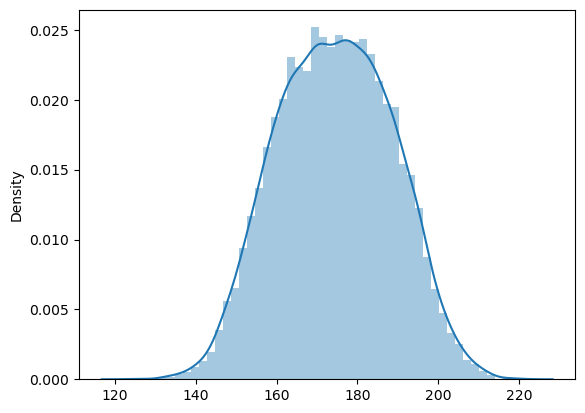

In [27]:
sns.distplot(x=calories_df['Height'])
plt.show()

C:\Users\CSC\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


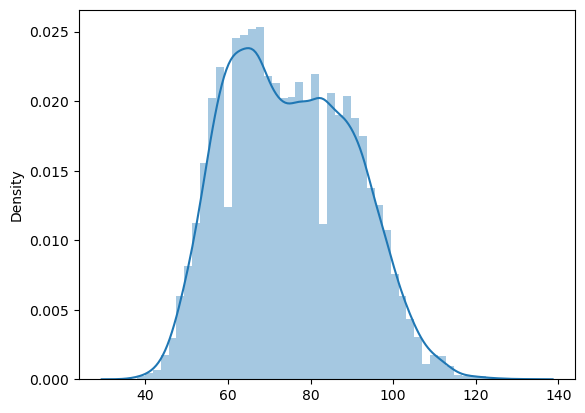

In [28]:
sns.distplot(x=calories_df['Weight'])
plt.show()

In [29]:
corelation = calories_df.corr()

In [30]:
corelation

,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
Age,1.000000,0.009376,0.089911,0.013475,0.010650,0.013485,0.154599
Height,0.009376,1.000000,0.958446,-0.004485,0.000632,0.001392,0.017648
Weight,0.089911,0.958446,1.000000,-0.001726,0.004429,0.004313,0.035608
Duration,0.013475,-0.004485,-0.001726,1.000000,0.852855,0.903154,0.955419
Heart_Rate,0.010650,0.000632,0.004429,0.852855,1.000000,0.771514,0.897872
Body_Temp,0.013485,0.001392,0.004313,0.903154,0.771514,1.000000,0.824550
Calories,0.154599,0.017648,0.035608,0.955419,0.897872,0.824550,1.000000


<AxesSubplot:>

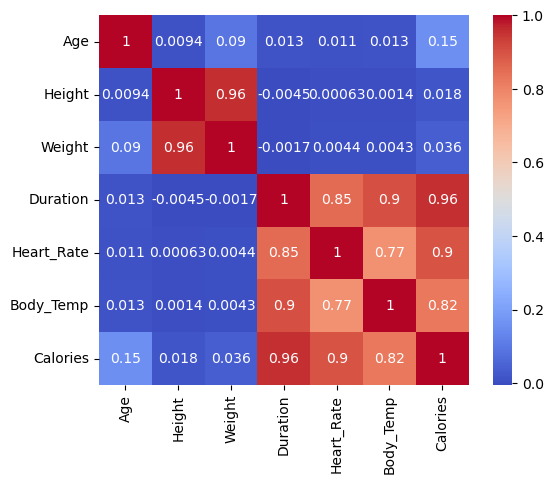

In [31]:
sns.heatmap(corelation,cbar=True,square=True,annot=True, cmap='coolwarm')

In [32]:
# Map gender categories to numeric values
gender_map = {'male': 0, 'female': 1}
calories_df['Gender'] = calories_df['Gender'].map(gender_map)

In [33]:
#Splitting training and testing

In [34]:

X= calories_df.drop('Calories',axis=1)
y = calories_df['Calories']

In [35]:
X.shape

(14999, 7)

In [36]:
y.shape

(14999,)

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Training and Testing Model

In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRFRegressor
from sklearn.metrics import mean_squared_error,r2_score

In [40]:
models = {
    'lr':LinearRegression(),
    "rfr":RandomForestRegressor(),
    'dtr':DecisionTreeRegressor(),
    'xg':XGBRFRegressor()
}

for name, mod in models.items():
    mod.fit(X_train,y_train)
    ypred = mod.predict(X_test)
    print(f"{name}  mse: {mean_squared_error(y_test,ypred)} r2 score: {r2_score(y_test,ypred)}")
    

lr  mse: 127.36619679233493 r2 score: 0.9668596949278279
rfr  mse: 7.7315952333333335 r2 score: 0.9979882619472026
dtr  mse: 26.593 r2 score: 0.9930805806016082
xg  mse: 61.97192813653633 r2 score: 0.9838750888691125


In [41]:
#Selecting model

In [42]:
model = RandomForestRegressor()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

## Prediction

In [43]:
def pred(Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp):
    features = np.array([[Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp]])
    prediction = model.predict(features).reshape(1,-1)
    return prediction[0]

Gender = 1
Age = 36
Height = 167.0
Weight = 64.0
Duration = 28.0
Heart_Rate = 108.0
Body_Temp = 40.0


result = pred(Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp)
print("you consumed this much calories",result)

you consumed this much calories [180.83]


C:\Users\CSC\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [44]:
import pickle
pickle.dump(model,open('model.pkl','wb'))

In [45]:
X_train.to_csv('X_train.csv')

In [46]:
pd.read_csv("X_train.csv")

,Unnamed: 0,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,8135,0,43,176,76,14,88,40.2
1,11050,0,21,187,84,5,81,39.2
2,13658,0,63,173,76,7,90,39.2
3,5946,0,50,197,96,9,88,39.6
4,8358,1,35,173,73,26,101,40.8
...,...,...,...,...,...,...,...,...
11994,11798,1,49,178,71,12,98,39.9
11995,13896,1,67,159,58,23,101,40.4
11996,6637,1,25,167,64,20,100,40.4
11997,2575,1,36,167,64,28,108,40.8
